# Anti-Money Laundering — Naive Bayes
## Comparación: GaussianNB estándar vs GaussianNB con `partial_fit`

**Métodos de búsqueda:**  
Grid Search · Random Search · Bayesiano (Optuna/TPE) · Genético (DEAP)


## Sección 1 · Imports y Configuración

In [2]:
!pip install deap optuna imbalanced-learn -q

import warnings, time, random
import scipy.sparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import loguniform

from sklearn.base             import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.naive_bayes      import GaussianNB
from sklearn.preprocessing    import StandardScaler
from sklearn.model_selection  import (
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc,
    f1_score, roc_auc_score,
)

from imblearn.pipeline        import Pipeline
from imblearn.over_sampling   import SMOTE, ADASYN
from imblearn.base            import BaseSampler

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from deap import base, creator, tools, algorithms

warnings.filterwarnings("ignore")
sns.set_theme(style='ticks', context='paper', font_scale=1.2, palette='Set1')

In [15]:
# ── Constantes globales ────────────────────────────────────────────────────────
RANDOM_STATE    = 42
N_SPLITS        = 3       # TimeSeriesSplit folds (cronológico)
N_ITER_RANDOM   = 20      # Random Search: iteraciones totales
N_TRIALS_OPTUNA = 30      # Optuna: trials totales
POP_SIZE        = 10      # DEAP: tamaño de la población
N_GEN           = 5       # DEAP: número de generaciones
BATCH_SIZE      = 5_000   # partial_fit: tamaño del mini-batch
BASE_PATH       = '/content/drive/MyDrive/Datasets/Final Project/Processed/'

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

RESULTS = {}

## Sección 2 · Clases Auxiliares

In [4]:
class ToDense(BaseEstimator, TransformerMixin):
    """Convierte matrices dispersas (sparse) a densas (ndarray). Necesario para GaussianNB."""
    def fit(self, X, y=None):   return self
    def transform(self, X):
        if scipy.sparse.issparse(X):
            return X.toarray()
        return np.array(X)


class IdentitySampler(BaseSampler):
    """
    Sampler identidad: devuelve (X, y) sin ninguna modificación.
    Representa la estrategia 'sin balanceo' dentro del espacio de búsqueda,
    permitiendo comparar directamente con SMOTE y ADASYN en el mismo experimento.
    _sampling_type = 'bypass' es reconocido por imblearn.Pipeline.
    """
    _sampling_type         = "bypass"
    _parameter_constraints = {}

    def _fit_resample(self, X, y):   return X, y
    def __repr__(self):              return "IdentitySampler()"


class GaussianNBPartialFitWrapper(BaseEstimator, ClassifierMixin):
    """
    Wrapper de GaussianNB que entrena usando partial_fit() en mini-batches.
    Habilita el aprendizaje incremental/online manteniendo compatibilidad sklearn.

    El Pipeline aplica el oversampling ANTES de que los datos lleguen a este
    estimador, por lo que fit() recibe X, y ya balanceados y los divide en
    mini-batches para alimentar a partial_fit.
    """
    def __init__(self, var_smoothing: float = 1e-9,
                 priors=None, batch_size: int = BATCH_SIZE):
        self.var_smoothing = var_smoothing
        self.priors        = priors
        self.batch_size    = batch_size

    def fit(self, X, y):
        classes = np.unique(y)
        self.model_ = GaussianNB(var_smoothing=self.var_smoothing,
                                 priors=list(self.priors) if self.priors else None)
        X_arr = X.toarray() if scipy.sparse.issparse(X) else np.array(X)
        y_arr = y.values if isinstance(y, pd.Series) else np.array(y)

        n = len(X_arr)
        for start in range(0, n, self.batch_size):
            end = min(start + self.batch_size, n)
            self.model_.partial_fit(X_arr[start:end], y_arr[start:end], classes=classes)
        return self

    def predict(self, X):
        X_arr = X.toarray() if scipy.sparse.issparse(X) else np.array(X)
        return self.model_.predict(X_arr)

    def predict_proba(self, X):
        X_arr = X.toarray() if scipy.sparse.issparse(X) else np.array(X)
        return self.model_.predict_proba(X_arr)

## Sección 3 · Carga de Datos

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
X_train = pd.read_parquet(f'{BASE_PATH}X_train.parquet')
X_test  = pd.read_parquet(f'{BASE_PATH}X_test.parquet')
y_train = pd.read_parquet(f'{BASE_PATH}y_train.parquet')['Is Laundering']
y_test  = pd.read_parquet(f'{BASE_PATH}y_test.parquet')['Is Laundering']

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"Prevalencia Lavado — Train: {y_train.mean():.4%} | Test: {y_test.mean():.4%}")

X_train : (4062668, 45) | y_train : (4062668,)
X_test  : (1015668, 45)  | y_test  : (1015668,)
Prevalencia Lavado — Train: 0.0832% | Test: 0.1770%


## Sección 4 · Configuraciones Compartidas y Helpers

### 4.1 Estrategias de balanceo

In [7]:
BALANCE_CONFIGS = [
    {'id': 0, 'name': 'Sin balanceo',     'priors': None},
    {'id': 1, 'name': 'SMOTE',            'priors': None},
    {'id': 2, 'name': 'ADASYN',           'priors': None},
    {'id': 3, 'name': 'priors=[0.5,0.5]', 'priors': [0.5, 0.5]},
]


def get_fresh_sampler(bal_id: int):
    """Retorna una instancia nueva del sampler para evitar estado residual."""
    if bal_id == 1: return SMOTE(random_state=RANDOM_STATE)
    if bal_id == 2: return ADASYN(random_state=RANDOM_STATE)
    return IdentitySampler()


def _sampler_label(params: dict) -> str:
    """Etiqueta legible del mejor parámetro de balanceo (usado en Grid/Random Search)."""
    sampler = params.get("sampler", None)
    priors  = params.get("clf__priors", None) or params.get("clf__priors", None)
    name    = type(sampler).__name__
    if name == "IdentitySampler":
        return "priors=[0.5,0.5]" if priors else "Sin balanceo"
    return name

### 4.2 Espacios de búsqueda (Grid y Random Search)

In [8]:
# ── Espacio Grid Search ────────────────────────────────────────────────────────
# 9 valores de var_smoothing × 4 estrategias de balanceo = 36 combinaciones
VS_GRID = np.logspace(-9, -1, 9)   # [1e-9, 1e-8, ..., 1e-1]

PARAM_GRID = [
    # Estrategia 0: sin balanceo
    {'sampler': [IdentitySampler()],
     'clf__var_smoothing': VS_GRID, 'clf__priors': [None]},
    # Estrategia 3: priors balanceados
    {'sampler': [IdentitySampler()],
     'clf__var_smoothing': VS_GRID, 'clf__priors': [(0.5, 0.5)]},
    # Estrategia 1: SMOTE
    {'sampler': [SMOTE(random_state=RANDOM_STATE)],
     'clf__var_smoothing': VS_GRID, 'clf__priors': [None]},
    # Estrategia 2: ADASYN
    {'sampler': [ADASYN(random_state=RANDOM_STATE)],
     'clf__var_smoothing': VS_GRID, 'clf__priors': [None]},
]

# ── Espacio Random Search ──────────────────────────────────────────────────────
# Distribuciones continuas para var_smoothing; sampler y priors son discretos
PARAM_DIST = [
    {'sampler': [IdentitySampler()],
     'clf__var_smoothing': loguniform(1e-9, 1e-1),
     'clf__priors': [None, (0.5, 0.5)]},
    {'sampler': [SMOTE(random_state=RANDOM_STATE),
                 ADASYN(random_state=RANDOM_STATE)],
     'clf__var_smoothing': loguniform(1e-9, 1e-1),
     'clf__priors': [None]},
]

### 4.3 Helpers de convergencia

In [9]:
def converged_optuna(study, patience: int = 10) -> bool:
    """True si el mejor valor acumulado no mejoró en los últimos `patience` trials."""
    vals = [t.value for t in study.trials if t.value is not None]
    if len(vals) < patience:
        return False
    best = [max(vals[:i + 1]) for i in range(len(vals))]
    return len(set(best[-patience:])) == 1


def converged_deap(logbook, patience: int = 2) -> bool:
    """True si el F1 máximo no mejoró en las últimas `patience` generaciones."""
    maxes = logbook.select('max')
    if len(maxes) <= patience:
        return False
    return maxes[-1] == maxes[-(patience + 1)]

### 4.4 Helpers DEAP

In [10]:
# Individuo NB: 2 genes
#   gene 0 → bal_id_float  ∈ [0.0, 3.999) → round → int 0-3
#   gene 1 → log10_vs      ∈ [-9.0, -1.0] → 10^gene = var_smoothing

def decode_individual(ind):
    """Traduce los 2 genes del individuo a parámetros interpretables."""
    bal_id        = int(np.clip(int(ind[0]), 0, 3))
    var_smoothing = 10 ** float(np.clip(ind[1], -9.0, -1.0))
    return bal_id, var_smoothing


def mutate_individual(individual, indpb: float):
    """Mutación con restricciones de rango por gen."""
    if random.random() < indpb: individual[0] = random.uniform(0.0, 3.999)
    if random.random() < indpb: individual[1] = random.uniform(-9.0, -1.0)
    return individual,


def _init_deap_toolbox(evaluate_fn, X_train, y_train):
    """Registra los operadores DEAP y retorna el toolbox configurado."""
    if hasattr(creator, 'FitnessMax'): del creator.FitnessMax
    if hasattr(creator, 'Individual'): del creator.Individual
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
    creator.create('Individual', list,         fitness=creator.FitnessMax)

    cv = TimeSeriesSplit(n_splits=N_SPLITS)

    toolbox = base.Toolbox()
    toolbox.register('attr_bal',    random.uniform, 0.0, 3.999)
    toolbox.register('attr_log_vs', random.uniform, -9.0, -1.0)
    toolbox.register(
        'individual', tools.initCycle, creator.Individual,
        (toolbox.attr_bal, toolbox.attr_log_vs), n=1,
    )
    toolbox.register('population', tools.initRepeat, list, toolbox.individual)
    toolbox.register('evaluate',   evaluate_fn, X=X_train, y=y_train, cv=cv)
    toolbox.register('mate',   tools.cxTwoPoint)
    toolbox.register('mutate', mutate_individual, indpb=0.3)
    toolbox.register('select', tools.selTournament, tournsize=3)
    return toolbox


def _run_deap(toolbox, pop_size: int, n_gen: int):
    """Ejecuta eaSimple y retorna (best_ind, logbook, elapsed_min)."""
    pop   = toolbox.population(n=pop_size)
    hof   = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register('avg', np.mean)
    stats.register('max', np.max)

    t0 = time.time()
    pop, logbook = algorithms.eaSimple(
        pop, toolbox, cxpb=0.5, mutpb=0.3,
        ngen=n_gen, stats=stats, halloffame=hof, verbose=True,
    )
    elapsed = (time.time() - t0) / 60
    return hof[0], logbook, elapsed

### 4.5 CV manual para partial_fit

In [11]:
def _cv_manual_pf(bal_id: int, var_smoothing: float, X, y,
                  batch_size: int = BATCH_SIZE) -> float:
    """
    Validación cruzada manual para GaussianNB con partial_fit.
    Flujo por fold:
      1. StandardScaler.fit_transform(X_train_fold)
      2. Oversampling con get_fresh_sampler(bal_id)
      3. partial_fit en mini-batches sobre los datos balanceados
      4. F1 sobre el fold de validación
    """
    tscv    = TimeSeriesSplit(n_splits=N_SPLITS)
    classes = np.array([0, 1])
    priors  = BALANCE_CONFIGS[bal_id]['priors']

    X_arr = X.values if isinstance(X, pd.DataFrame) else np.array(X)
    y_arr = y.values if isinstance(y, pd.Series)    else np.array(y)

    f1_scores = []
    for train_idx, val_idx in tscv.split(X_arr):
        X_tr, y_tr = X_arr[train_idx], y_arr[train_idx]
        X_va, y_va = X_arr[val_idx],   y_arr[val_idx]

        # 1. Escalar
        scaler  = StandardScaler()
        X_tr_sc = scaler.fit_transform(X_tr)
        X_va_sc = scaler.transform(X_va)

        # 2. Oversampling (todo el fold antes de dividir en batches)
        sampler = get_fresh_sampler(bal_id)
        try:
            X_res, y_res = sampler.fit_resample(X_tr_sc, y_tr)
        except Exception:
            X_res, y_res = X_tr_sc, y_tr

        y_res_arr = y_res if isinstance(y_res, np.ndarray) else y_res.values

        # 3. partial_fit en mini-batches
        nb = GaussianNB(var_smoothing=var_smoothing,
                        priors=list(priors) if priors else None)
        n = len(X_res)
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)
            nb.partial_fit(X_res[start:end], y_res_arr[start:end], classes=classes)

        # 4. Evaluar
        y_pred = nb.predict(X_va_sc)
        f1_scores.append(f1_score(y_va, y_pred, zero_division=0))

    return float(np.mean(f1_scores))

### 4.6 Construcción y predicción del modelo final

In [12]:
def build_final_model(spec: dict, X_train, y_train):
    """
    Reconstruye y entrena el modelo final sobre todo X_train.
    spec = {
        'nb_config'    : 'standard' | 'partial_fit',
        'bal_id'       : int,
        'var_smoothing': float,
    }
    """
    bal_cfg = BALANCE_CONFIGS[spec['bal_id']]
    sampler = get_fresh_sampler(spec['bal_id'])
    priors  = bal_cfg['priors']

    if spec['nb_config'] == 'standard':
        pipe = Pipeline([
            ('scaler',   StandardScaler(with_mean=False)),
            ('to_dense', ToDense()),
            ('sampler',  sampler),
            ('clf',      GaussianNB(var_smoothing=spec['var_smoothing'],
                                    priors=list(priors) if priors else None)),
        ])
        pipe.fit(X_train, y_train)
        return pipe

    else:   # partial_fit
        scaler = StandardScaler(with_mean=False)
        X_sc   = scaler.fit_transform(X_train)
        if scipy.sparse.issparse(X_sc):
            X_sc = X_sc.toarray()
        else:
            X_sc = np.array(X_sc)

        X_res, y_res = sampler.fit_resample(X_sc, y_train)
        y_arr = y_res if isinstance(y_res, np.ndarray) else y_res.values

        classes = np.array([0, 1])
        nb = GaussianNB(var_smoothing=spec['var_smoothing'],
                        priors=list(priors) if priors else None)
        n = len(X_res)
        for start in range(0, n, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n)
            nb.partial_fit(X_res[start:end], y_arr[start:end], classes=classes)

        return (scaler, nb)


def predict_final(model, X_test):
    """Genera (y_pred, y_proba) para cualquier tipo de modelo final."""
    if isinstance(model, Pipeline):
        return model.predict(X_test), model.predict_proba(X_test)[:, 1]
    else:   # tupla (scaler, nb) de partial_fit
        scaler, nb = model
        X_sc = scaler.transform(X_test)
        if scipy.sparse.issparse(X_sc):
            X_sc = X_sc.toarray()
        else:
            X_sc = np.array(X_sc)
        return nb.predict(X_sc), nb.predict_proba(X_sc)[:, 1]

### 4.7 Visualización del historial de búsqueda

In [13]:
def plot_search_history(gs: GridSearchCV, model_name: str) -> None:
    """Genera la distribución de F1 por estrategia y la curva de convergencia."""
    cv_df = pd.DataFrame(gs.cv_results_)
    cv_df["estrategia"] = cv_df["params"].apply(_sampler_label)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Panel 1: distribución de F1 por estrategia
    order = (
        cv_df.groupby("estrategia")["mean_test_score"]
        .median().sort_values(ascending=False).index.tolist()
    )
    sns.boxplot(
        data=cv_df, x="estrategia", y="mean_test_score",
        order=order, ax=axes[0], palette="Set2", width=0.5,
    )
    axes[0].set_title("F1 (CV) por estrategia de balanceo", fontweight="bold")
    axes[0].set_xlabel("Estrategia")
    axes[0].set_ylabel(f"F1 promedio ({N_SPLITS}-fold TimeSeriesSplit)")
    axes[0].tick_params(axis="x", rotation=15)
    for patch in axes[0].patches:
        patch.set_alpha(0.8)
    for i, strat in enumerate(order):
        med = cv_df.loc[cv_df["estrategia"] == strat, "mean_test_score"].median()
        axes[0].text(i, med + 0.002, f"{med:.4f}",
                     ha="center", va="bottom", fontsize=8, fontweight="bold")

    # Panel 2: curva de convergencia acumulada
    scores      = cv_df["mean_test_score"].values
    best_so_far = np.maximum.accumulate(scores)

    axes[1].plot(best_so_far, color="steelblue", lw=2.5, label="Mejor F1 acumulado")
    axes[1].scatter(
        np.argmax(scores == gs.best_score_), gs.best_score_,
        s=120, zorder=5, color="red",
        label=f"Óptimo global = {gs.best_score_:.4f}",
    )
    axes[1].fill_between(range(len(best_so_far)), 0, best_so_far,
                          alpha=0.08, color="steelblue")
    axes[1].axhline(gs.best_score_, color="red", linestyle="--", lw=1.2, alpha=0.5)
    axes[1].set_xlabel("Combinación evaluada (orden de búsqueda)")
    axes[1].set_ylabel("Mejor F1 hasta esa iteración")
    axes[1].set_title("Convergencia de la búsqueda", fontweight="bold")
    axes[1].legend(frameon=False)

    sns.despine()
    plt.suptitle(f"Historial de Optimización — {model_name}",
                 fontweight="bold", fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

## Sección 5 · GaussianNB (standard) — Grid Search

══════════════════════════════════════════════════════════════
 Grid Search — GaussianNB (standard)
══════════════════════════════════════════════════════════════
 Combinaciones totales       : 36
 Entrenamientos CV           : 108
 Esquema de validación       : TimeSeriesSplit(n_splits=3)
 Métrica principal           : F1 (clase minoritaria = Lavado)
Fitting 3 folds for each of 36 candidates, totalling 108 fits

══════════════════════════════════════════════════════════════
 ✓ Grid Search completado en 11.7 min
 Combinaciones evaluadas     : 36
 Mejor F1 (CV)               : 0.0098
 Mejor balanceo              : Sin balanceo
 var_smoothing óptimo        : 1.00e-01
══════════════════════════════════════════════════════════════


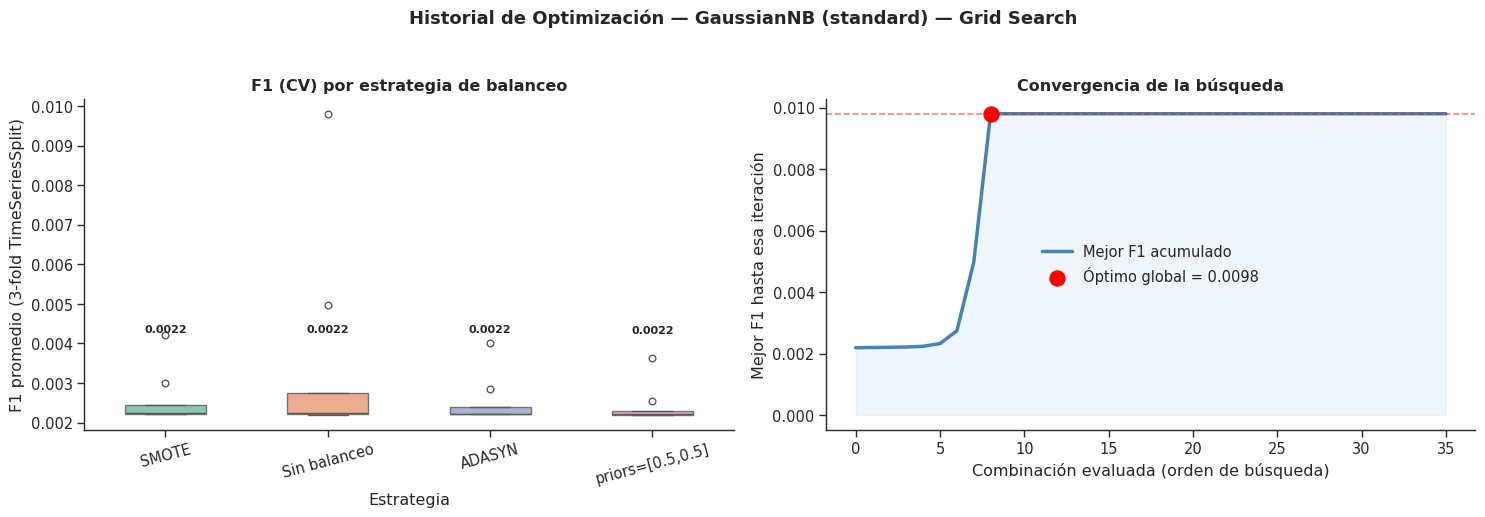

In [16]:
def run_grid_search_std(X_train, y_train):
    n_combos = sum(
        len(d['clf__var_smoothing']) * len(d.get('clf__priors', [None]))
        for d in PARAM_GRID
    )

    print(f"{'═'*62}")
    print(f" Grid Search — GaussianNB (standard)")
    print(f"{'═'*62}")
    print(f" Combinaciones totales       : {n_combos}")
    print(f" Entrenamientos CV           : {n_combos * N_SPLITS}")
    print(f" Esquema de validación       : TimeSeriesSplit(n_splits={N_SPLITS})")
    print(f" Métrica principal           : F1 (clase minoritaria = Lavado)")

    pipe = Pipeline([
        ('scaler',   StandardScaler(with_mean=False)),
        ('to_dense', ToDense()),
        ('sampler',  IdentitySampler()),
        ('clf',      GaussianNB()),
    ])

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    gs   = GridSearchCV(
        estimator          = pipe,
        param_grid         = PARAM_GRID,
        cv                 = tscv,
        scoring            = 'f1',
        n_jobs             = 2,
        verbose            = 1,
        refit              = True,
        return_train_score = True,
        error_score        = 0.0,
    )

    t0 = time.time()
    gs.fit(X_train, y_train)
    elapsed = (time.time() - t0) / 60

    best_p   = gs.best_params_
    bal_name = _sampler_label(best_p)
    best_vs  = best_p['clf__var_smoothing']
    best_priors = best_p.get('clf__priors', None)

    # Determinar bal_id desde los best_params
    sname = type(best_p['sampler']).__name__
    if sname == 'SMOTE':                                    best_bal_id = 1
    elif sname == 'ADASYN':                                 best_bal_id = 2
    elif best_priors is not None and best_priors != None:   best_bal_id = 3
    else:                                                   best_bal_id = 0

    print(f"\n{'═'*62}")
    print(f" ✓ Grid Search completado en {elapsed:.1f} min")
    print(f" Combinaciones evaluadas     : {len(gs.cv_results_['params'])}")
    print(f" Mejor F1 (CV)               : {gs.best_score_:.4f}")
    print(f" Mejor balanceo              : {bal_name}")
    print(f" var_smoothing óptimo        : {best_vs:.2e}")
    print(f"{'═'*62}")

    RESULTS['std_grid'] = {
        'label'       : 'GaussianNB (standard)',
        'method'      : 'Grid Search',
        'best_f1'     : gs.best_score_,
        'time_min'    : round(elapsed, 2),
        'n_evals'     : len(gs.cv_results_['params']),
        'converged'   : 'N/A',
        'best_balance': bal_name,
        'best_vs'     : best_vs,
        'spec'        : {'nb_config': 'standard', 'bal_id': best_bal_id,
                         'var_smoothing': best_vs},
        'gs'          : gs,
    }
    return gs


gs_std = run_grid_search_std(X_train, y_train)
plot_search_history(gs_std, "GaussianNB (standard) — Grid Search")

## Sección 6 · GaussianNB (standard) — Random Search

══════════════════════════════════════════════════════════════
 Random Search — GaussianNB (standard)
══════════════════════════════════════════════════════════════
 Iteraciones totales         : 20
 var_smoothing               : loguniform [1e-9, 1e-1]  (continuo)
 Estrategias de balanceo     : Sin balanceo · SMOTE · ADASYN · priors=[0.5,0.5]
Fitting 3 folds for each of 20 candidates, totalling 60 fits

══════════════════════════════════════════════════════════════
 ✓ Random Search completado en 6.6 min
 Iteraciones evaluadas       : 20
 Mejor F1 (CV)               : 0.0047
 Mejor balanceo              : Sin balanceo
 var_smoothing óptimo        : 8.50e-03
══════════════════════════════════════════════════════════════


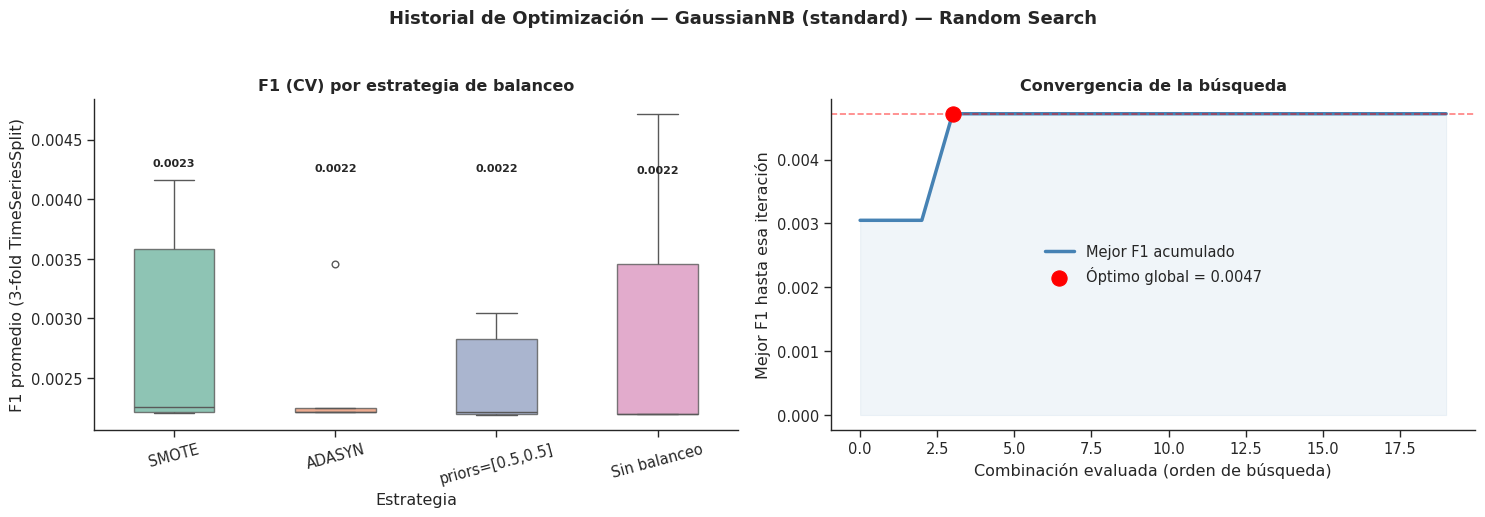

In [17]:
def run_random_search_std(X_train, y_train, n_iter: int = N_ITER_RANDOM):
    print(f"{'═'*62}")
    print(f" Random Search — GaussianNB (standard)")
    print(f"{'═'*62}")
    print(f" Iteraciones totales         : {n_iter}")
    print(f" var_smoothing               : loguniform [1e-9, 1e-1]  (continuo)")
    print(f" Estrategias de balanceo     : Sin balanceo · SMOTE · ADASYN · priors=[0.5,0.5]")

    pipe = Pipeline([
        ('scaler',   StandardScaler(with_mean=False)),
        ('to_dense', ToDense()),
        ('sampler',  IdentitySampler()),
        ('clf',      GaussianNB()),
    ])

    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    rs   = RandomizedSearchCV(
        estimator          = pipe,
        param_distributions= PARAM_DIST,
        n_iter             = n_iter,
        cv                 = tscv,
        scoring            = 'f1',
        n_jobs             = 2,
        verbose            = 1,
        refit              = True,
        return_train_score = True,
        random_state       = RANDOM_STATE,
        error_score        = 0.0,
    )

    t0 = time.time()
    rs.fit(X_train, y_train)
    elapsed = (time.time() - t0) / 60

    best_p   = rs.best_params_
    bal_name = _sampler_label(best_p)
    best_vs  = best_p['clf__var_smoothing']
    best_priors = best_p.get('clf__priors', None)

    sname = type(best_p['sampler']).__name__
    if sname == 'SMOTE':                                    best_bal_id = 1
    elif sname == 'ADASYN':                                 best_bal_id = 2
    elif best_priors is not None and best_priors != None:   best_bal_id = 3
    else:                                                   best_bal_id = 0

    print(f"\n{'═'*62}")
    print(f" ✓ Random Search completado en {elapsed:.1f} min")
    print(f" Iteraciones evaluadas       : {len(rs.cv_results_['params'])}")
    print(f" Mejor F1 (CV)               : {rs.best_score_:.4f}")
    print(f" Mejor balanceo              : {bal_name}")
    print(f" var_smoothing óptimo        : {best_vs:.2e}")
    print(f"{'═'*62}")

    RESULTS['std_random'] = {
        'label'       : 'GaussianNB (standard)',
        'method'      : 'Random Search',
        'best_f1'     : rs.best_score_,
        'time_min'    : round(elapsed, 2),
        'n_evals'     : len(rs.cv_results_['params']),
        'converged'   : 'N/A',
        'best_balance': bal_name,
        'best_vs'     : best_vs,
        'spec'        : {'nb_config': 'standard', 'bal_id': best_bal_id,
                         'var_smoothing': best_vs},
        'gs'          : rs,
    }
    return rs


rs_std = run_random_search_std(X_train, y_train)
plot_search_history(rs_std, "GaussianNB (standard) — Random Search")

## Sección 7 · GaussianNB (standard) — Bayesiano (Optuna / TPE)

In [18]:
def run_optuna_std(X_train, y_train, n_trials: int = N_TRIALS_OPTUNA):
    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — GaussianNB (standard)")
    print(f"{'═'*62}")
    print(f" Trials totales              : {n_trials}")

    def objective(trial):
        bal_id        = trial.suggest_int  ('bal_id',        0,    3)
        var_smoothing = trial.suggest_float('var_smoothing', 1e-9, 1e-1, log=True)

        bal_cfg = BALANCE_CONFIGS[bal_id]
        priors  = bal_cfg['priors']

        pipe = Pipeline([
            ('scaler',   StandardScaler(with_mean=False)),
            ('to_dense', ToDense()),
            ('sampler',  get_fresh_sampler(bal_id)),
            ('clf',      GaussianNB(var_smoothing=var_smoothing,
                                    priors=list(priors) if priors else None)),
        ])
        tscv = TimeSeriesSplit(n_splits=N_SPLITS)
        try:
            scores = cross_val_score(pipe, X_train, y_train,
                                     cv=tscv, scoring='f1',
                                     n_jobs=1, error_score=0.0)
            return float(scores.mean())
        except Exception:
            return 0.0

    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=RANDOM_STATE))
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best      = study.best_trial
    best_bal  = best.params['bal_id']
    best_vs   = best.params['var_smoothing']
    bal_name  = BALANCE_CONFIGS[best_bal]['name']

    print(f"\n{'═'*62}")
    print(f" ✓ Optuna (standard) completado en {elapsed:.1f} min")
    print(f" Trials completados          : {len(study.trials)}")
    print(f" Mejor F1 (CV)               : {best.value:.4f}")
    print(f" Mejor balanceo              : {bal_name}")
    print(f" var_smoothing               : {best_vs:.2e}")
    print(f" ¿Convergió?                 : {converged_optuna(study)}")
    print(f"{'═'*62}")

    RESULTS['std_optuna'] = {
        'label'       : 'GaussianNB (standard)',
        'method'      : 'Bayesiano',
        'best_f1'     : best.value,
        'time_min'    : round(elapsed, 2),
        'n_evals'     : len(study.trials),
        'converged'   : converged_optuna(study),
        'best_balance': bal_name,
        'best_vs'     : best_vs,
        'spec'        : {'nb_config': 'standard', 'bal_id': best_bal,
                         'var_smoothing': best_vs},
        'study'       : study,
    }
    return study


study_std = run_optuna_std(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — GaussianNB (standard)
══════════════════════════════════════════════════════════════
 Trials totales              : 30


  0%|          | 0/30 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
 ✓ Optuna (standard) completado en 11.9 min
 Trials completados          : 30
 Mejor F1 (CV)               : 0.0095
 Mejor balanceo              : Sin balanceo
 var_smoothing               : 9.25e-02
 ¿Convergió?                 : False
══════════════════════════════════════════════════════════════


## Sección 8 · GaussianNB (standard) — DEAP (Algoritmo Genético)

In [19]:
def evaluate_individual_std(individual, X, y, cv):
    """Función de fitness para DEAP con GaussianNB estándar."""
    bal_id, var_smoothing = decode_individual(individual)
    bal_cfg = BALANCE_CONFIGS[bal_id]
    priors  = bal_cfg['priors']

    pipe = Pipeline([
        ('scaler',   StandardScaler(with_mean=False)),
        ('to_dense', ToDense()),
        ('sampler',  get_fresh_sampler(bal_id)),
        ('clf',      GaussianNB(var_smoothing=var_smoothing,
                                priors=list(priors) if priors else None)),
    ])
    try:
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1',
                                 n_jobs=1, error_score=0.0)
        return (float(scores.mean()),)
    except Exception:
        return (0.0,)


def run_deap_std(X_train, y_train, pop_size: int = POP_SIZE, n_gen: int = N_GEN):
    print(f"{'═'*62}")
    print(f" DEAP (Genético) — GaussianNB (standard)")
    print(f"{'═'*62}")
    print(f" Población: {pop_size} | Generaciones: {n_gen} | "
          f"Evaluaciones ≈ {pop_size * n_gen}")

    toolbox         = _init_deap_toolbox(evaluate_individual_std, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, var_smoothing = decode_individual(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    best_f1  = best_ind.fitness.values[0]

    print(f"\n{'═'*62}")
    print(f" ✓ DEAP (standard) completado en {elapsed:.1f} min")
    print(f" Mejor F1 (CV)               : {best_f1:.4f}")
    print(f" Mejor balanceo              : {bal_name}")
    print(f" var_smoothing               : {var_smoothing:.2e}")
    print(f" ¿Convergió?                 : {converged_deap(logbook)}")
    print(f"{'═'*62}")

    RESULTS['std_deap'] = {
        'label'       : 'GaussianNB (standard)',
        'method'      : 'DEAP (Genético)',
        'best_f1'     : best_f1,
        'time_min'    : round(elapsed, 2),
        'n_evals'     : pop_size * n_gen,
        'converged'   : converged_deap(logbook),
        'best_balance': bal_name,
        'best_vs'     : var_smoothing,
        'spec'        : {'nb_config': 'standard', 'bal_id': bal_id,
                         'var_smoothing': var_smoothing},
        'logbook'     : logbook,
    }
    return best_ind, logbook


best_std_deap, logbook_std = run_deap_std(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — GaussianNB (standard)
══════════════════════════════════════════════════════════════
 Población: 10 | Generaciones: 5 | Evaluaciones ≈ 50
gen	nevals	avg       	max       
0  	10    	0.00223055	0.00231565
1  	7     	0.00267931	0.00647504
2  	5     	0.0036383 	0.00734818
3  	7     	0.00557399	0.00734818
4  	10    	0.00556564	0.00734818
5  	6     	0.00547611	0.00734818

══════════════════════════════════════════════════════════════
 ✓ DEAP (standard) completado en 16.2 min
 Mejor F1 (CV)               : 0.0073
 Mejor balanceo              : Sin balanceo
 var_smoothing               : 4.25e-02
 ¿Convergió?                 : True
══════════════════════════════════════════════════════════════


## Sección 9 · GaussianNB (partial_fit) — Bayesiano (Optuna / TPE)

In [20]:
def run_optuna_pf(X_train, y_train, n_trials: int = N_TRIALS_OPTUNA):
    print(f"{'═'*62}")
    print(f" Bayesiano (Optuna/TPE) — GaussianNB (partial_fit)")
    print(f"{'═'*62}")
    print(f" Trials totales              : {n_trials}")
    print(f" Batch size                  : {BATCH_SIZE:,} muestras")

    def objective(trial):
        bal_id        = trial.suggest_int  ('bal_id',        0,    3)
        var_smoothing = trial.suggest_float('var_smoothing', 1e-9, 1e-1, log=True)
        try:
            return _cv_manual_pf(bal_id, var_smoothing, X_train, y_train)
        except Exception:
            return 0.0

    study = optuna.create_study(direction='maximize',
                                sampler=TPESampler(seed=RANDOM_STATE))
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    elapsed = (time.time() - t0) / 60

    best      = study.best_trial
    best_bal  = best.params['bal_id']
    best_vs   = best.params['var_smoothing']
    bal_name  = BALANCE_CONFIGS[best_bal]['name']

    print(f"\n{'═'*62}")
    print(f" ✓ Optuna (partial_fit) completado en {elapsed:.1f} min")
    print(f" Trials completados          : {len(study.trials)}")
    print(f" Mejor F1 (CV)               : {best.value:.4f}")
    print(f" Mejor balanceo              : {bal_name}")
    print(f" var_smoothing               : {best_vs:.2e}")
    print(f" ¿Convergió?                 : {converged_optuna(study)}")
    print(f"{'═'*62}")

    RESULTS['pf_optuna'] = {
        'label'       : 'GaussianNB (partial_fit)',
        'method'      : 'Bayesiano',
        'best_f1'     : best.value,
        'time_min'    : round(elapsed, 2),
        'n_evals'     : len(study.trials),
        'converged'   : converged_optuna(study),
        'best_balance': bal_name,
        'best_vs'     : best_vs,
        'spec'        : {'nb_config': 'partial_fit', 'bal_id': best_bal,
                         'var_smoothing': best_vs},
        'study'       : study,
    }
    return study


study_pf = run_optuna_pf(X_train, y_train)

══════════════════════════════════════════════════════════════
 Bayesiano (Optuna/TPE) — GaussianNB (partial_fit)
══════════════════════════════════════════════════════════════
 Trials totales              : 30
 Batch size                  : 5,000 muestras


  0%|          | 0/30 [00:00<?, ?it/s]


══════════════════════════════════════════════════════════════
 ✓ Optuna (partial_fit) completado en 11.0 min
 Trials completados          : 30
 Mejor F1 (CV)               : 0.0111
 Mejor balanceo              : Sin balanceo
 var_smoothing               : 9.25e-02
 ¿Convergió?                 : False
══════════════════════════════════════════════════════════════


## Sección 10 · GaussianNB (partial_fit) — DEAP (Algoritmo Genético)

In [21]:
def evaluate_individual_pf(individual, X, y, cv):
    """Función de fitness para DEAP con GaussianNB partial_fit."""
    bal_id, var_smoothing = decode_individual(individual)
    try:
        return (_cv_manual_pf(bal_id, var_smoothing, X, y),)
    except Exception:
        return (0.0,)


def run_deap_pf(X_train, y_train, pop_size: int = POP_SIZE, n_gen: int = N_GEN):
    print(f"{'═'*62}")
    print(f" DEAP (Genético) — GaussianNB (partial_fit)")
    print(f"{'═'*62}")
    print(f" Población: {pop_size} | Generaciones: {n_gen} | "
          f"Evaluaciones ≈ {pop_size * n_gen}")

    toolbox         = _init_deap_toolbox(evaluate_individual_pf, X_train, y_train)
    best_ind, logbook, elapsed = _run_deap(toolbox, pop_size, n_gen)

    bal_id, var_smoothing = decode_individual(best_ind)
    bal_name = BALANCE_CONFIGS[bal_id]['name']
    best_f1  = best_ind.fitness.values[0]

    print(f"\n{'═'*62}")
    print(f" ✓ DEAP (partial_fit) completado en {elapsed:.1f} min")
    print(f" Mejor F1 (CV)               : {best_f1:.4f}")
    print(f" Mejor balanceo              : {bal_name}")
    print(f" var_smoothing               : {var_smoothing:.2e}")
    print(f" ¿Convergió?                 : {converged_deap(logbook)}")
    print(f"{'═'*62}")

    RESULTS['pf_deap'] = {
        'label'       : 'GaussianNB (partial_fit)',
        'method'      : 'DEAP (Genético)',
        'best_f1'     : best_f1,
        'time_min'    : round(elapsed, 2),
        'n_evals'     : pop_size * n_gen,
        'converged'   : converged_deap(logbook),
        'best_balance': bal_name,
        'best_vs'     : var_smoothing,
        'spec'        : {'nb_config': 'partial_fit', 'bal_id': bal_id,
                         'var_smoothing': var_smoothing},
        'logbook'     : logbook,
    }
    return best_ind, logbook


best_pf_deap, logbook_pf = run_deap_pf(X_train, y_train)

══════════════════════════════════════════════════════════════
 DEAP (Genético) — GaussianNB (partial_fit)
══════════════════════════════════════════════════════════════
 Población: 10 | Generaciones: 5 | Evaluaciones ≈ 50
gen	nevals	avg       	max       
0  	10    	0.00267671	0.00596664
1  	6     	0.00456523	0.00878464
2  	5     	0.0045707 	0.00878464
3  	9     	0.00699791	0.00878464
4  	8     	0.008134  	0.00878464
5  	8     	0.00811253	0.00878464

══════════════════════════════════════════════════════════════
 ✓ DEAP (partial_fit) completado en 14.5 min
 Mejor F1 (CV)               : 0.0088
 Mejor balanceo              : Sin balanceo
 var_smoothing               : 5.02e-02
 ¿Convergió?                 : True
══════════════════════════════════════════════════════════════


## Sección 11 · Tabla Comparativa y Análisis de Convergencia

### 11.1 Tabla de Resultados

           Configuración Método de Búsqueda  Mejor F1-Score (CV)  Tiempo Total (min)  Iteraciones/Evaluaciones ¿Convergió? Mejor Balanceo var_smoothing
   GaussianNB (standard)        Grid Search             0.009806               11.65                        36         N/A   Sin balanceo      1.00e-01
   GaussianNB (standard)      Random Search             0.004718                6.62                        20         N/A   Sin balanceo      8.50e-03
   GaussianNB (standard)          Bayesiano             0.009504               11.92                        30       False   Sin balanceo      9.25e-02
   GaussianNB (standard)    DEAP (Genético)             0.007348               16.20                        50        True   Sin balanceo      4.25e-02
GaussianNB (partial_fit)          Bayesiano             0.011099               11.03                        30       False   Sin balanceo      9.25e-02
GaussianNB (partial_fit)    DEAP (Genético)             0.008785               14.46    

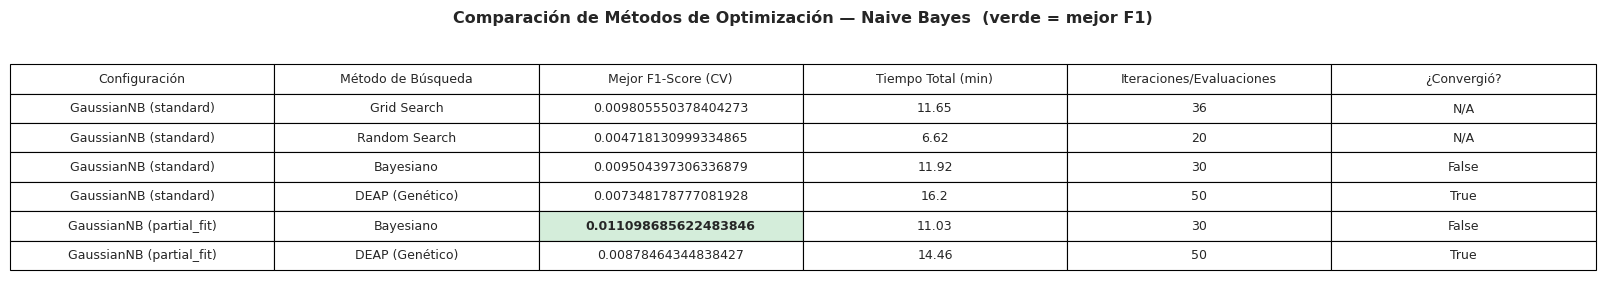

In [22]:
ORDER = ['std_grid', 'std_random', 'std_optuna', 'std_deap', 'pf_optuna', 'pf_deap']

rows = []
for k in ORDER:
    r = RESULTS[k]
    rows.append({
        'Configuración'            : r['label'],
        'Método de Búsqueda'       : r['method'],
        'Mejor F1-Score (CV)'      : r['best_f1'],
        'Tiempo Total (min)'       : r['time_min'],
        'Iteraciones/Evaluaciones' : r['n_evals'],
        '¿Convergió?'              : r['converged'],
        'Mejor Balanceo'           : r['best_balance'],
        'var_smoothing'            : f"{r['best_vs']:.2e}",
    })

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False))

# Visualización de la tabla con resaltado del mejor F1
display_cols = ['Configuración', 'Método de Búsqueda', 'Mejor F1-Score (CV)',
                'Tiempo Total (min)', 'Iteraciones/Evaluaciones', '¿Convergió?']

fig, ax = plt.subplots(figsize=(16, 3.2))
ax.axis('off')
tbl = ax.table(
    cellText  = comparison_df[display_cols].values,
    colLabels = display_cols,
    cellLoc   = 'center',
    loc       = 'center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

best_row = comparison_df['Mejor F1-Score (CV)'].idxmax()
f1_col   = display_cols.index('Mejor F1-Score (CV)')
tbl[best_row + 1, f1_col].set_facecolor('#d4edda')
tbl[best_row + 1, f1_col].set_text_props(fontweight='bold')

plt.title('Comparación de Métodos de Optimización — Naive Bayes  (verde = mejor F1)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}tabla_comparacion_nb.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.2 Convergencia Bayesiana (Optuna)

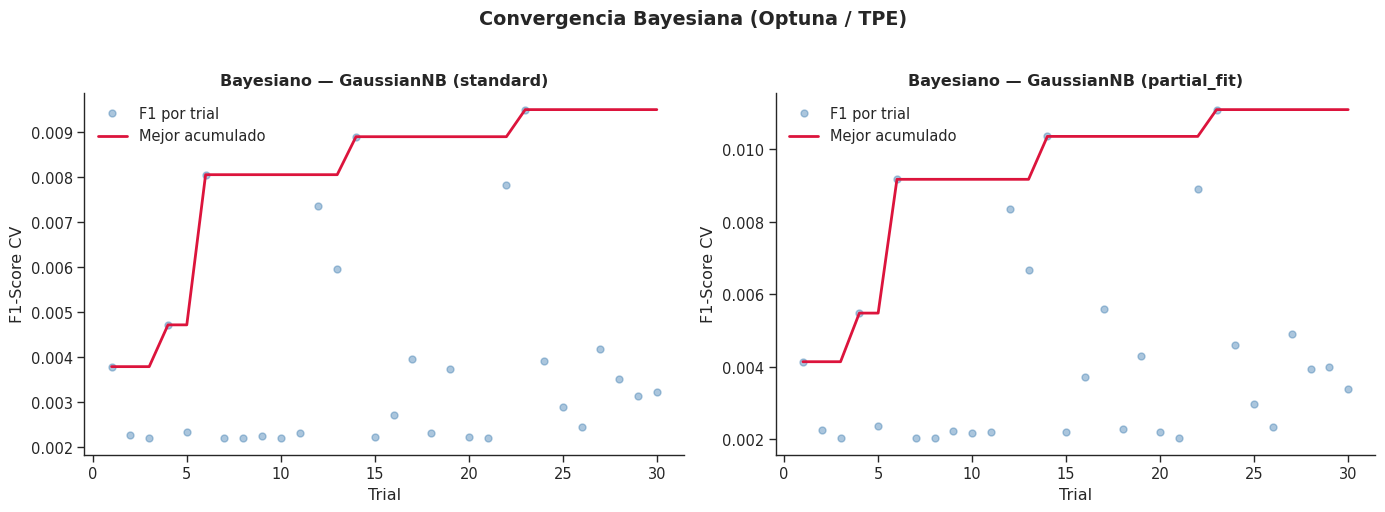

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'std_optuna', 'Bayesiano — GaussianNB (standard)'),
    (axes[1], 'pf_optuna',  'Bayesiano — GaussianNB (partial_fit)'),
]:
    study      = RESULTS[key]['study']
    trial_f1   = [t.value for t in study.trials if t.value is not None]
    best_so_far = [max(trial_f1[:i + 1]) for i in range(len(trial_f1))]

    ax.plot(range(1, len(trial_f1) + 1), trial_f1,
            'o', color='steelblue', alpha=0.45, ms=5, label='F1 por trial')
    ax.plot(range(1, len(best_so_far) + 1), best_so_far,
            '-', color='crimson', lw=2, label='Mejor acumulado')
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1-Score CV')
    ax.set_title(title, fontweight='bold')
    ax.legend(frameon=False)
    sns.despine(ax=ax)

plt.suptitle('Convergencia Bayesiana (Optuna / TPE)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_optuna_nb.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Convergencia Genética (DEAP)

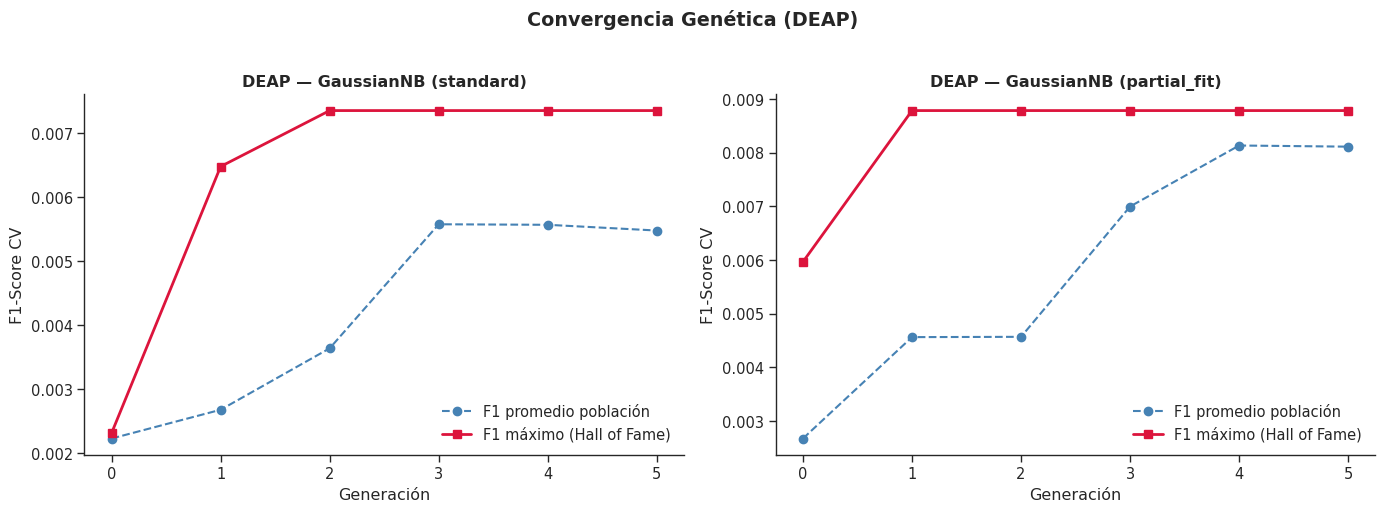

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, key, title in [
    (axes[0], 'std_deap', 'DEAP — GaussianNB (standard)'),
    (axes[1], 'pf_deap',  'DEAP — GaussianNB (partial_fit)'),
]:
    lb   = RESULTS[key]['logbook']
    gens = lb.select('gen')
    avgs = lb.select('avg')
    maxs = lb.select('max')

    ax.plot(gens, avgs, 'o--', color='steelblue', lw=1.5, ms=6,
            label='F1 promedio población')
    ax.plot(gens, maxs, 's-',  color='crimson',   lw=2,   ms=6,
            label='F1 máximo (Hall of Fame)')
    ax.set_xlabel('Generación')
    ax.set_ylabel('F1-Score CV')
    ax.set_title(title, fontweight='bold')
    ax.legend(frameon=False)
    sns.despine(ax=ax)

plt.suptitle('Convergencia Genética (DEAP)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE_PATH}convergencia_deap_nb.png', dpi=150, bbox_inches='tight')
plt.show()

### 11.4 Eficiencia: F1 vs Tiempo

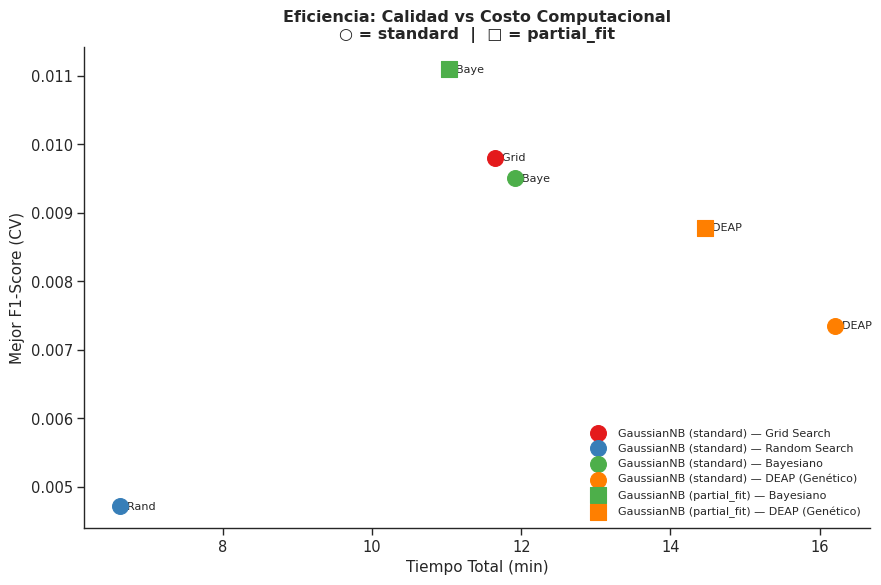

In [25]:
colors_method  = {
    'Grid Search'    : '#E41A1C',
    'Random Search'  : '#377EB8',
    'Bayesiano'      : '#4DAF4A',
    'DEAP (Genético)': '#FF7F00',
}
markers_config = {
    'GaussianNB (standard)'    : 'o',
    'GaussianNB (partial_fit)' : 's',
}

fig, ax = plt.subplots(figsize=(9, 6))

for k in ORDER:
    r = RESULTS[k]
    ax.scatter(
        r['time_min'], r['best_f1'],
        color  = colors_method[r['method']],
        marker = markers_config[r['label']],
        s      = 130, zorder=5,
        label  = f"{r['label']} — {r['method']}",
    )
    ax.annotate(
        f"  {r['method'][:4]}",
        (r['time_min'], r['best_f1']),
        fontsize=8, va='center',
    )

ax.set_xlabel('Tiempo Total (min)', fontsize=11)
ax.set_ylabel('Mejor F1-Score (CV)', fontsize=11)
ax.set_title('Eficiencia: Calidad vs Costo Computacional\n'
             '○ = standard  |  □ = partial_fit', fontweight='bold')
ax.legend(frameon=False, fontsize=8, loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig(f'{BASE_PATH}eficiencia_nb.png', dpi=150, bbox_inches='tight')
plt.show()

## Sección 12 · Evaluación Final y Exportación del Mejor Modelo

### 12.1 Identificar la mejor configuración

In [26]:
best_key = max(RESULTS, key=lambda k: RESULTS[k]['best_f1'])
best_res = RESULTS[best_key]

print(f"{'═'*62}")
print(f" MEJOR CONFIGURACIÓN GLOBAL")
print(f"{'═'*62}")
print(f" Modelo          : {best_res['label']}")
print(f" Método          : {best_res['method']}")
print(f" F1-Score (CV)   : {best_res['best_f1']:.4f}")
print(f" Balanceo        : {best_res['best_balance']}")
print(f" var_smoothing   : {best_res['best_vs']:.2e}")
print(f"{'═'*62}\n")

══════════════════════════════════════════════════════════════
 MEJOR CONFIGURACIÓN GLOBAL
══════════════════════════════════════════════════════════════
 Modelo          : GaussianNB (partial_fit)
 Método          : Bayesiano
 F1-Score (CV)   : 0.0111
 Balanceo        : Sin balanceo
 var_smoothing   : 9.25e-02
══════════════════════════════════════════════════════════════



### 12.2 Refit en todo X_train

In [27]:
print("Entrenando modelo final en todo X_train...")
final_model = build_final_model(best_res['spec'], X_train, y_train)
print("Modelo final entrenado ✓\n")

Entrenando modelo final en todo X_train...
Modelo final entrenado ✓



### 12.3 Predicciones sobre test

In [28]:
y_pred_final, y_proba_final = predict_final(final_model, X_test)

### 12.4 Evaluación completa

══════════════════════════════════════════════════════════════
 EVALUACIÓN FINAL EN TEST — GaussianNB (partial_fit) — Bayesiano
══════════════════════════════════════════════════════════════
 Accuracy          : 0.9020
 Precision Lavado  : 0.0160
 Recall    Lavado  : 0.8999
 F1-Score  Lavado  : 0.0315  ◄
 ROC-AUC           : 0.9445
 PR-AUC            : 0.0496

              precision    recall  f1-score   support

    Legítima       1.00      0.90      0.95   1013870
      Lavado       0.02      0.90      0.03      1798

    accuracy                           0.90   1015668
   macro avg       0.51      0.90      0.49   1015668
weighted avg       1.00      0.90      0.95   1015668



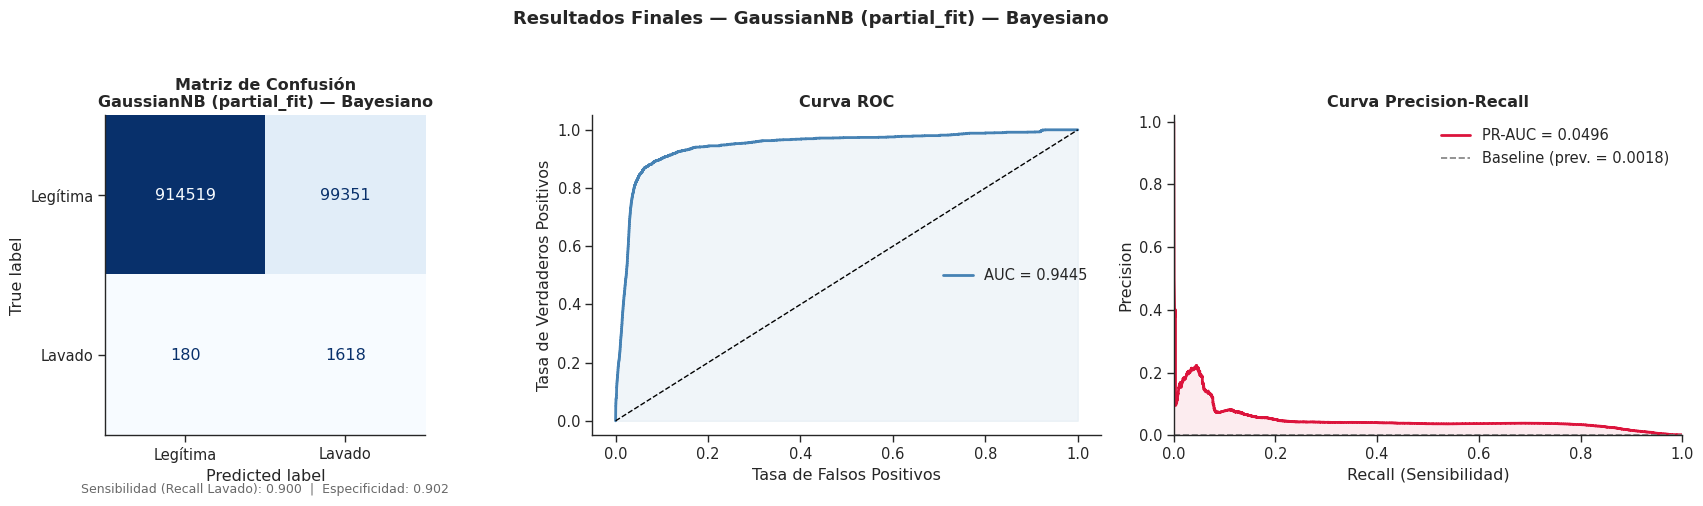

In [29]:
def evaluate_final_model(y_true, y_pred, y_proba, title: str) -> dict:
    """
    Imprime métricas y genera tres paneles:
      1. Matriz de confusión
      2. Curva ROC
      3. Curva Precision-Recall
    """
    report  = classification_report(y_true, y_pred,
                                     target_names=['Legítima', 'Lavado'],
                                     output_dict=True)
    prec_c, rec_c, _ = precision_recall_curve(y_true, y_proba)
    fpr, tpr, _      = roc_curve(y_true, y_proba)
    pr_auc  = auc(rec_c, prec_c)
    roc_auc = auc(fpr, tpr)

    print(f"{'═'*62}")
    print(f" EVALUACIÓN FINAL EN TEST — {title}")
    print(f"{'═'*62}")
    print(f" Accuracy          : {report['accuracy']:.4f}")
    print(f" Precision Lavado  : {report['Lavado']['precision']:.4f}")
    print(f" Recall    Lavado  : {report['Lavado']['recall']:.4f}")
    print(f" F1-Score  Lavado  : {report['Lavado']['f1-score']:.4f}  ◄")
    print(f" ROC-AUC           : {roc_auc:.4f}")
    print(f" PR-AUC            : {pr_auc:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Legítima', 'Lavado'])}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1 — Matriz de confusión
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Legítima', 'Lavado'],
    ).plot(ax=axes[0], cmap='Blues', colorbar=False)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    axes[0].set_title(f'Matriz de Confusión\n{title}', fontweight='bold')
    axes[0].text(
        0.5, -0.18,
        f"Sensibilidad (Recall Lavado): {tp/(tp+fn):.3f}  |  "
        f"Especificidad: {tn/(tn+fp):.3f}",
        transform=axes[0].transAxes, ha='center', fontsize=9, color='dimgray',
    )

    # Panel 2 — Curva ROC
    axes[1].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[1].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend(frameon=False)

    # Panel 3 — Curva Precision-Recall
    axes[2].plot(rec_c, prec_c, lw=2, color='crimson', label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y_true.mean(), color='gray', linestyle='--', lw=1.2,
                    label=f'Baseline (prev. = {y_true.mean():.4f})')
    axes[2].fill_between(rec_c, prec_c, alpha=0.08, color='crimson')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Curva Precision-Recall', fontweight='bold')
    axes[2].legend(frameon=False)
    axes[2].set_xlim([0, 1])
    axes[2].set_ylim([0, 1.02])

    sns.despine()
    plt.suptitle(f'Resultados Finales — {title}',
                 fontweight='bold', fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig(f'{BASE_PATH}evaluacion_final_nb.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'roc_auc': roc_auc, 'pr_auc': pr_auc,
            'f1_lavado': report['Lavado']['f1-score']}


eval_metrics = evaluate_final_model(
    y_test, y_pred_final, y_proba_final,
    title=f"{best_res['label']} — {best_res['method']}",
)

### 12.5 Exportaciones

In [30]:
# Probabilidades para Comparacion_Benchmarks.ipynb (Test de DeLong + Bootstrap)
pd.DataFrame({'y_proba_nb': y_proba_final}).to_parquet(
    f'{BASE_PATH}y_proba_nb.parquet', index=False
)

# Modelo serializado
joblib.dump(final_model, f'{BASE_PATH}model_nb.joblib')

# Tabla de comparación
comparison_df.to_csv(f'{BASE_PATH}tabla_comparacion_nb.csv', index=False)

print(f"\n{'═'*62}")
print(f" Archivos exportados a Drive:")
print(f"   ✓ y_proba_nb.parquet          (para Comparacion_Benchmarks.ipynb)")
print(f"   ✓ model_nb.joblib             (modelo final serializado)")
print(f"   ✓ tabla_comparacion_nb.csv    (resultados de todos los métodos)")
print(f"   ✓ tabla_comparacion_nb.png")
print(f"   ✓ convergencia_optuna_nb.png")
print(f"   ✓ convergencia_deap_nb.png")
print(f"   ✓ eficiencia_nb.png")
print(f"   ✓ evaluacion_final_nb.png")
print(f"{'═'*62}")


══════════════════════════════════════════════════════════════
 Archivos exportados a Drive:
   ✓ y_proba_nb.parquet          (para Comparacion_Benchmarks.ipynb)
   ✓ model_nb.joblib             (modelo final serializado)
   ✓ tabla_comparacion_nb.csv    (resultados de todos los métodos)
   ✓ tabla_comparacion_nb.png
   ✓ convergencia_optuna_nb.png
   ✓ convergencia_deap_nb.png
   ✓ eficiencia_nb.png
   ✓ evaluacion_final_nb.png
══════════════════════════════════════════════════════════════
